In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from keras import backend as K
from keras import utils as utls
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense

c:\Users\Marcelo\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.5) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# Definição de Hiperparâmetros
imageRows, imageCols = 28, 28
batchSize = 256
numClasses = 10
epochs = 10
cores = 1

In [8]:
(XTrain, yTrain), (XTest, yTest) = mnist.load_data()
XTrain = XTrain.astype('float32')
XTest = XTest.astype('float32')
XTrain = XTrain / 255.0
XTest = XTest / 255.0
yTrain = utls.to_categorical(yTrain, numClasses)
yTest = utls.to_categorical(yTest, numClasses)

In [ ]:
XTrain.shape

In [4]:
inputShape = (imageRows, imageCols, cores)

In [5]:
model = Sequential()
model.add(Conv2D(20, (5,5), padding='same', input_shape=inputShape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2))
model.add(Conv2D(50, (5,5), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2))
model.add(Flatten())
model.add(Dense(500))
model.add(Activation('relu'))
model.add(Dense(numClasses))
model.add(Activation('softmax'))
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 20)        520       
                                                                 
 activation (Activation)     (None, 28, 28, 20)        0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 20)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 50)        25050     
                                                                 
 activation_1 (Activation)   (None, 14, 14, 50)        0         
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 7, 50)          0         
 g2D)                                                

In [6]:
model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])

In [9]:
minhaLeNetModel = model.fit(XTrain, yTrain, batch_size=batchSize, epochs=epochs, validation_data=(XTest, yTest))

Epoch 1/10


235/235 [==============================] - 34s 138ms/step - loss: 0.2162 - accuracy: 0.9336 - val_loss: 0.0572 - val_accuracy: 0.9799
Epoch 2/10
235/235 [==============================] - 30s 127ms/step - loss: 0.0534 - accuracy: 0.9836 - val_loss: 0.0364 - val_accuracy: 0.9879
Epoch 3/10
235/235 [==============================] - 30s 127ms/step - loss: 0.0350 - accuracy: 0.9891 - val_loss: 0.0308 - val_accuracy: 0.9893
Epoch 4/10
235/235 [==============================] - 31s 130ms/step - loss: 0.0277 - accuracy: 0.9912 - val_loss: 0.0286 - val_accuracy: 0.9889
Epoch 5/10
235/235 [==============================] - 31s 133ms/step - loss: 0.0200 - accuracy: 0.9939 - val_loss: 0.0242 - val_accuracy: 0.9916
Epoch 6/10
235/235 [==============================] - 32s 138ms/step - loss: 0.0163 - accuracy: 0.9948 - val_loss: 0.0297 - val_accuracy: 0.9898
Epoch 7/10
235/235 [==============================] - 30s 126ms/step - loss: 0.0124 - accuracy: 0.9959 - val_loss: 0.0227 - val_

Text(0, 0.5, 'Acurácia')

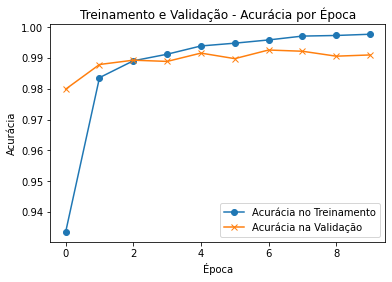

In [10]:
f, ax = plt.subplots()
ax.plot(minhaLeNetModel.history['accuracy'], 'o-')
ax.plot(minhaLeNetModel.history['val_accuracy'], 'x-')
ax.legend(['Acurácia no Treinamento', 'Acurácia na Validação'], loc=0)
ax.set_title('Treinamento e Validação - Acurácia por Época')
ax.set_xlabel('Época')
ax.set_ylabel('Acurácia')